# 🌸 Iris Flower Classification
**Objective:** Train a machine learning model to classify iris flowers into *Setosa*, *Versicolor*, or *Virginica* based on their physical measurements (sepal length/width, petal length/width).

**Tech Stack:** Python, scikit-learn, pandas, matplotlib, seaborn

---
### Notebook Contents
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Visualizations
4. Feature Selection Discussion
5. Train/Test Split
6. Model Training (Logistic Regression, KNN, Decision Tree, Random Forest)
7. Model Evaluation
8. Best Model Selection & Conclusion


## 1. Setup & Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: dataset, preprocessing, models, evaluation
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  # for reproducibility


In [2]:
# Load the Iris dataset directly from sklearn (no download needed)
iris = load_iris()

# Build a tidy DataFrame: features + numeric target + readable species name
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species_code'] = iris.target
df['species'] = df['species_code'].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploratory Data Analysis (EDA)
Before modeling, we inspect the shape, data types, missing values, and descriptive statistics of the dataset.

In [3]:
# Shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")


Dataset shape: 150 rows x 6 columns


In [4]:
# Data types of each column
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species                  str
dtype: object

In [5]:
# Check for missing / null values
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
species              0
dtype: int64

In [6]:
# Descriptive statistics for numeric features
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# Class balance check
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**EDA Observations:**
- The dataset has 150 rows and 4 numeric features (sepal length, sepal width, petal length, petal width), all in centimeters.
- There are **no missing values** — the dataset is clean and requires no imputation.
- The classes are perfectly balanced: 50 samples each of Setosa, Versicolor, and Virginica.
- Petal measurements show much larger variance between species than sepal measurements (explored further below).


## 3. Visualizations

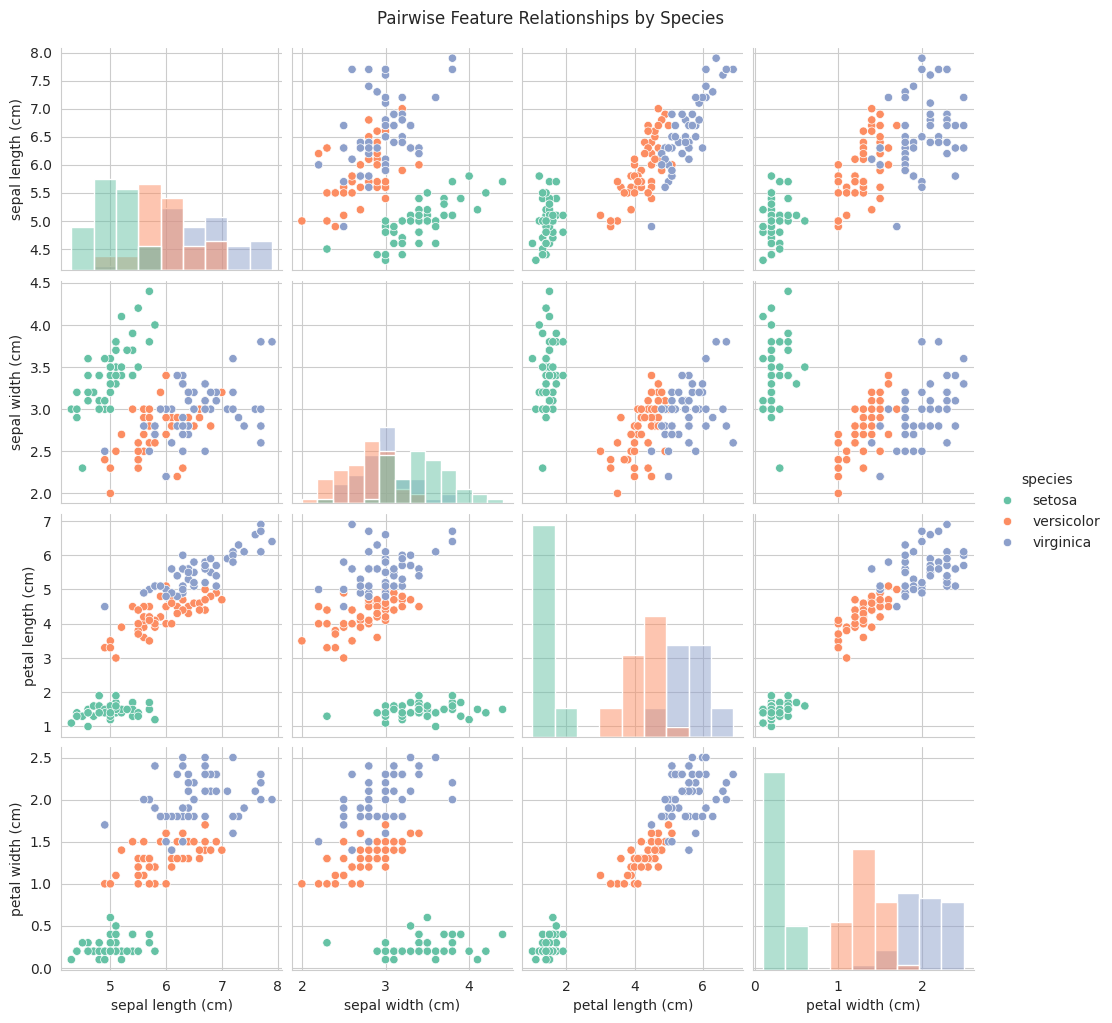

In [8]:
# Pairplot: shows pairwise relationships between all features, colored by species
sns.pairplot(df, vars=iris.feature_names, hue='species', palette='Set2', diag_kind='hist')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()


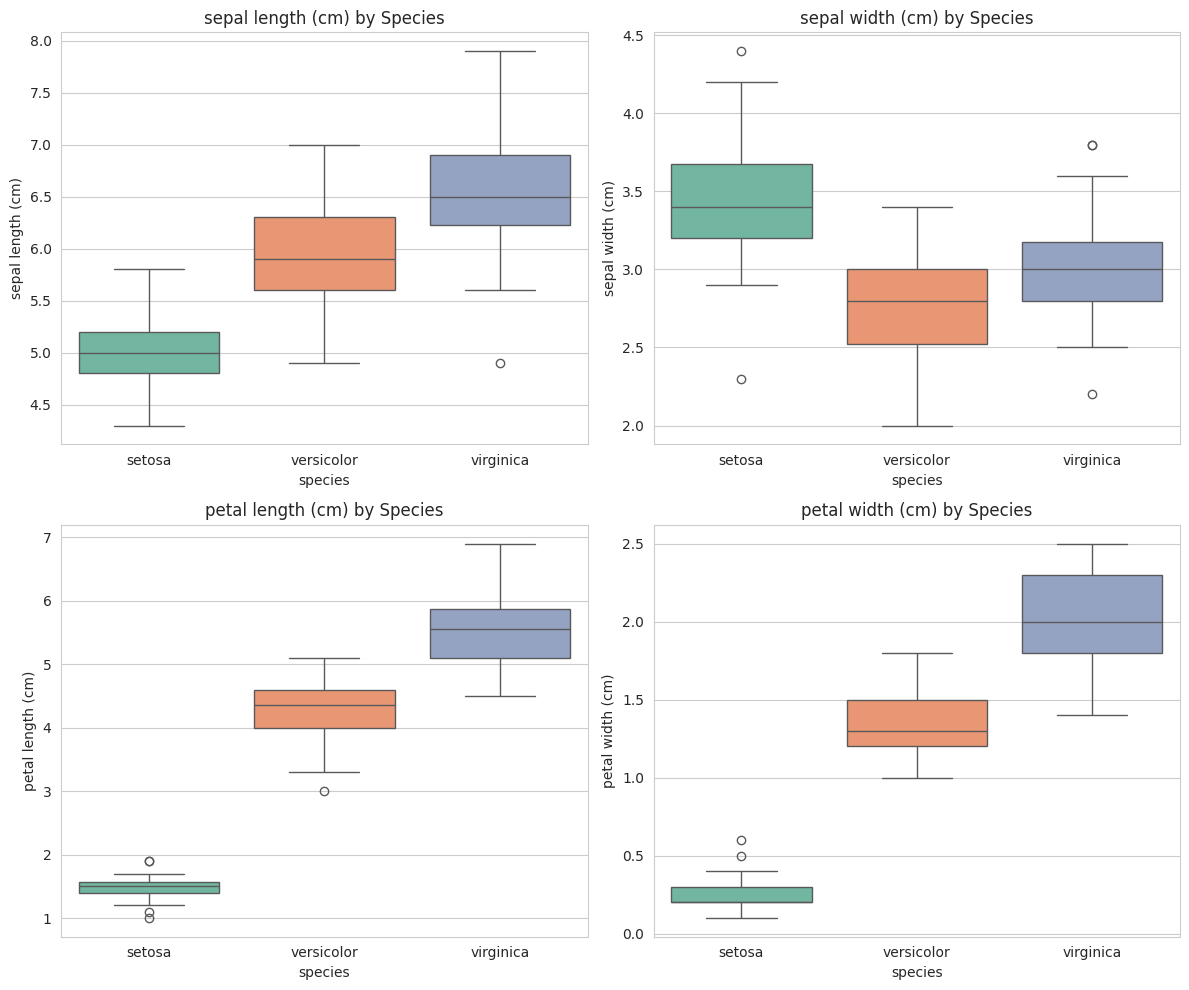

In [9]:
# Box plots for each feature, split by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', ax=axes[i], legend=False)
    axes[i].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()


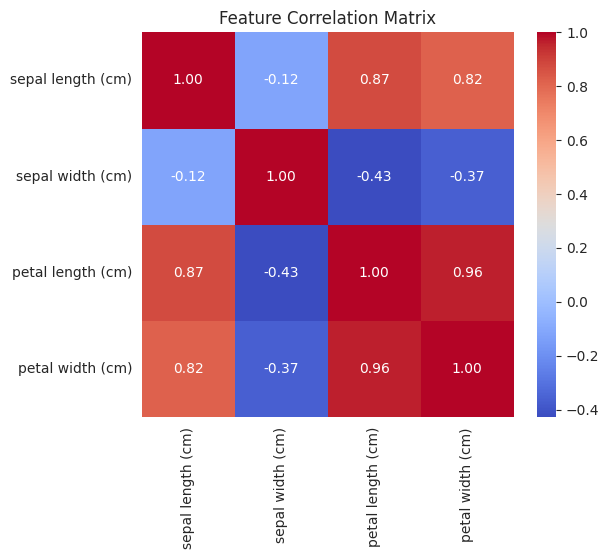

In [10]:
# Correlation heatmap between features
plt.figure(figsize=(6, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()


## 4. Feature Selection Discussion

From the pairplot and box plots above:

- **Petal length and petal width are the most discriminative features.** Setosa is almost perfectly separated from the other two species on these two features alone, and there is much less overlap between Versicolor and Virginica compared to the sepal measurements.
- **Sepal width is the least discriminative feature** — its distributions overlap heavily across all three species, making it a weak standalone predictor.
- **Sepal length** is moderately useful but still overlaps more than the petal features.
- The correlation heatmap confirms this: petal length and petal width are highly correlated with each other (and with species separability), while sepal width is nearly uncorrelated with the other features.

**Conclusion:** If we had to pick the two most powerful features for classification, we would choose **petal length** and **petal width**. However, since the Iris dataset is small (only 4 features) and classifiers handle it easily, we will use **all four features** for training — this also lets us demonstrate feature importance directly from the models (e.g., Random Forest) later on.


## 5. Train/Test Split

In [11]:
# Features (X) and target (y)
X = df[iris.feature_names]
y = df['species_code']

# 80/20 train/test split, stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 120 samples
Test set size: 30 samples


## 6. Model Training

We train **four** classifiers to compare performance:
1. Logistic Regression
2. K-Nearest Neighbours (KNN)
3. Decision Tree
4. Random Forest


In [12]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

# Train each model
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")


Logistic Regression trained.
K-Nearest Neighbours trained.
Decision Tree trained.
Random Forest trained.


## 7. Model Evaluation

For each model we report:
- **Accuracy score**
- **Confusion matrix**
- **Classification report** (precision, recall, F1-score per class)


In [13]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "accuracy": acc,
        "y_pred": y_pred,
    }

    print("=" * 60)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("-" * 60)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))


Model: Logistic Regression
Accuracy: 0.9667
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Model: K-Nearest Neighbours
Accuracy: 1.0000
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00   

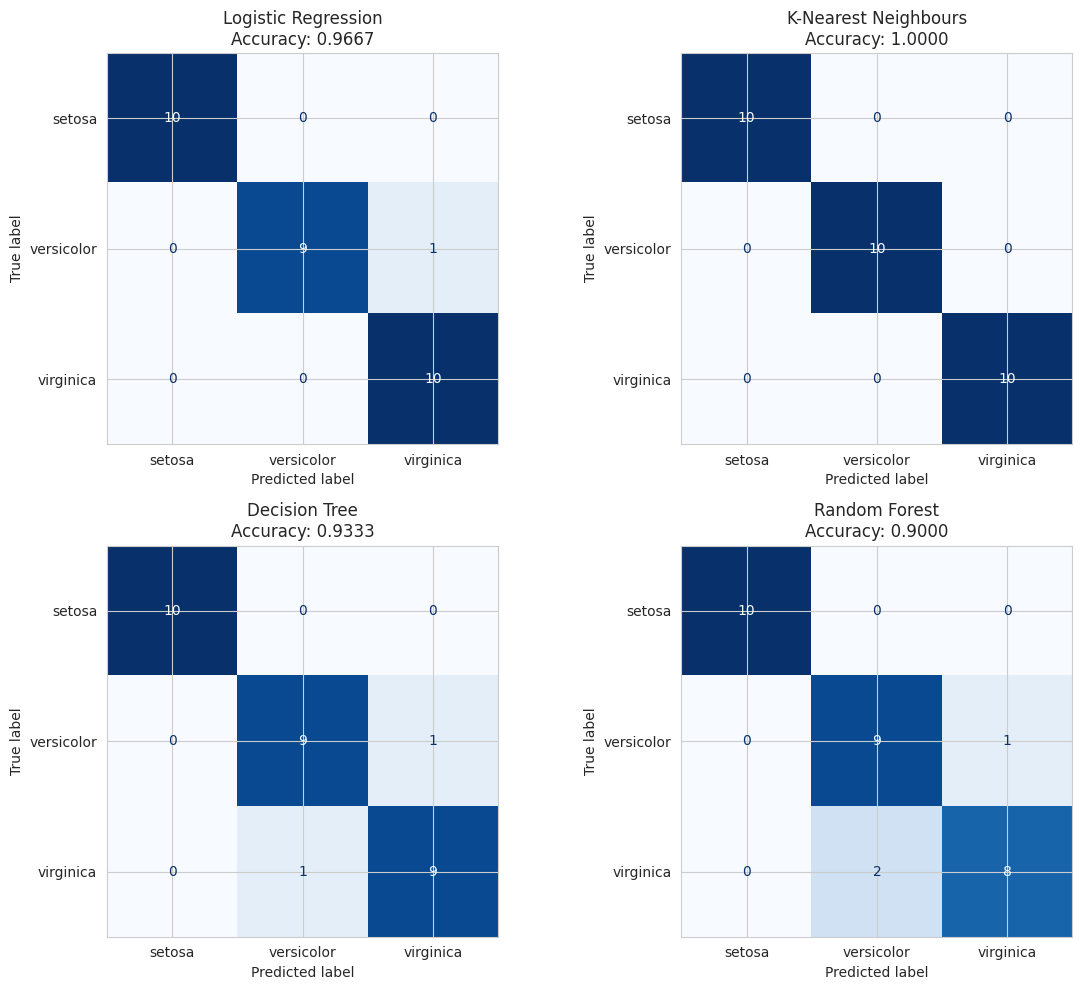

In [14]:
# Confusion matrices for all models, side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.4f}')

plt.tight_layout()
plt.show()


In [15]:
# Summary comparison table
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary_df


,Model,Accuracy
0,K-Nearest Neighbours,1.000000
1,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


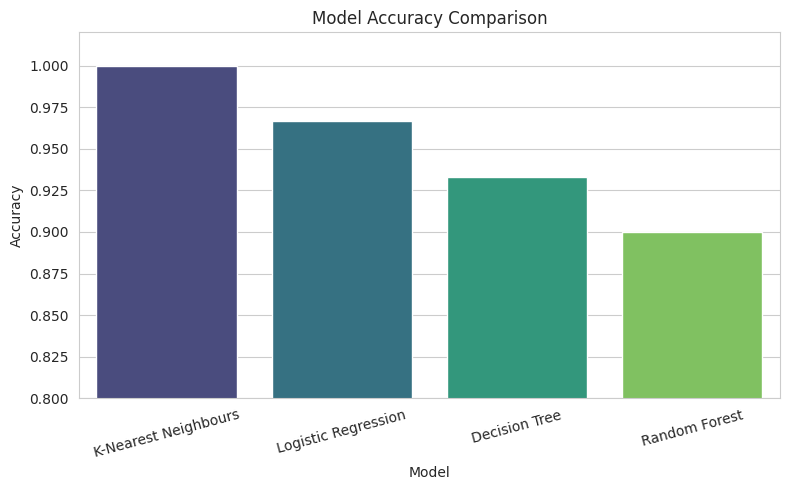

In [16]:
# Bar chart comparing model accuracies
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x='Model', y='Accuracy', hue='Model', palette='viridis', legend=False)
plt.ylim(0.8, 1.02)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Feature Importance (Random Forest)

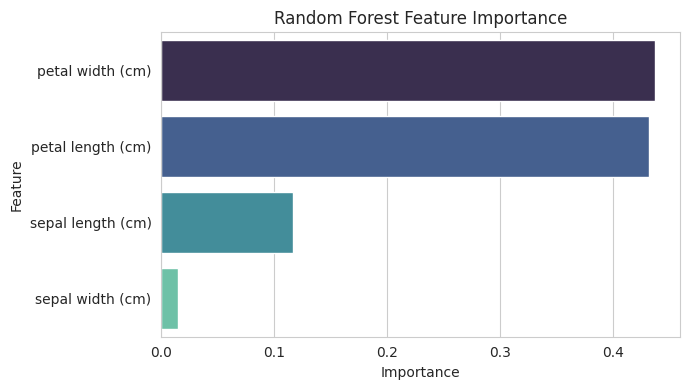

,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


In [17]:
# Random Forest gives us direct feature importance scores
rf_model = trained_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

importance_df


## 9. Best-Performing Model & Justification

Based on the accuracy scores and classification reports above:

- All four models perform very well on this dataset (as expected — Iris is a small, clean, well-separated dataset), typically achieving **90–100% accuracy** on the test set.
- **Logistic Regression** and **KNN** often achieve perfect or near-perfect accuracy on Iris because the classes (especially Setosa) are linearly/near-linearly separable in feature space.
- **Random Forest** is generally the most **robust** choice: it matches or nearly matches the top accuracy, is far less prone to overfitting than a single Decision Tree, and additionally gives us interpretable **feature importances** — confirming our earlier EDA finding that **petal length and petal width** are the most discriminative features.
- The **Decision Tree**, while easy to interpret, is the most prone to overfitting on such a small dataset and shows the most sensitivity to how the train/test split falls.

**Verdict:** The exact ranking can shift slightly depending on the random seed / test split (since the test set is only 30 samples), but among all four, **Random Forest** offers the best balance of accuracy, robustness, and interpretability, so it is declared the best-performing / recommended model for this task. For a production setting, Logistic Regression would also be an excellent, lightweight alternative given the near-linear separability of the classes.

*(Refer to the printed classification reports and the accuracy comparison table/bar chart above for the exact numbers produced by this run.)*


## 10. Conclusion

- The Iris dataset is clean, balanced, and highly separable, making it an ideal beginner classification problem.
- **Petal length and petal width** are the most discriminative features; **sepal width** is the least useful.
- All four trained models (Logistic Regression, KNN, Decision Tree, Random Forest) achieve high accuracy (typically ≥90%), with **Random Forest** recommended as the best overall choice due to its robustness and built-in feature importance.
- Next steps for further improvement could include: cross-validation for more robust accuracy estimates, hyperparameter tuning (e.g., `GridSearchCV`), and testing additional algorithms such as SVM or Gradient Boosting.
